<a href="https://colab.research.google.com/github/carter293/ds_project_h03_2024_group_c/blob/main/src/ZZSC9020_Project_Model_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysing the Dynamics: How the Rate of Temperature Change Impacts Electricity Demand Forecasting in Australia

### ZZSC9020 Data Science Project

### Matthew Carter, Ling Qian, Craig Hennessy, Zeina Zabaneh 

The proposed study is structured around three primary goals:

- To conduct exploratory data analysis (EDA) on the demand forecasts produced by Endgame Economics' with the aim of studying the effect of rate of temperature change on the accuracy and variance of the model.

- To develop a model capable of predicting next-day electricity demand, and

- To evaluate the impact of temperature change rates on the accuracy and variance of the model's predictions, with the aim of identifying strategies to improve forecasting reliability when confronted with rapid temperature changes.


## Data Preparation


In [ ]:
!pwd

/content


In [ ]:
# Clone the project repository from GitHub
!git clone https://github.com/carter293/ds_project_h03_2024_group_c_data.git

Cloning into 'ds_project_h03_2024_group_c_data'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 14 (delta 0), reused 5 (delta 0), pack-reused 9
Receiving objects: 100% (14/14), 109.70 MiB | 33.53 MiB/s, done.
Updating files: 100% (8/8), done.
Encountered 2 file(s) that should have been pointers, but weren't:
	data/NSW/temperature_nsw.csv.zip
	data/NSW/totaldemand_nsw.csv.zip


In [ ]:
%cd /content/ds_project_h03_2024_group_c_data
!ls data

/content/ds_project_h03_2024_group_c_data
NSW  NSW_Public_Holidays.csv  NSW_School_Holidays_2015_2022.csv


In [ ]:
# Create a data folder
!mkdir -p data
# Joint forecastdemand_nsw files into a single file.
!cat /content/ds_project_h03_2024_group_c_data/data/NSW/forecastdemand_nsw.csv.zip.part* > data/forecastdemand_nsw.csv.zip

In [ ]:
# Unzip the data files into the data folder
!unzip /content/ds_project_h03_2024_group_c_data/data/forecastdemand_nsw.csv.zip -d data
!unzip /content/ds_project_h03_2024_group_c_data/data/NSW/temperature_nsw.csv.zip -d data
!unzip /content/ds_project_h03_2024_group_c_data/data/NSW/totaldemand_nsw.csv.zip -d data

# Remove forecastdemand_nsw.csv.zip
!rm /content/ds_project_h03_2024_group_c_data/data/forecastdemand_nsw.csv.zip

Archive:  /content/ds_project_h03_2024_group_c_data/data/forecastdemand_nsw.csv.zip
  inflating: data/forecastdemand_nsw.csv  
Archive:  /content/ds_project_h03_2024_group_c_data/data/NSW/temperature_nsw.csv.zip
  inflating: data/temperature_nsw.csv  
Archive:  /content/ds_project_h03_2024_group_c_data/data/NSW/totaldemand_nsw.csv.zip
  inflating: data/totaldemand_nsw.csv  


In [ ]:
#import libraries
import pandas as pd
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.formula.api import ols
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
from keras.models import Sequential
from keras.layers import Dense, LSTM, Conv1D, MaxPooling1D, Flatten, TimeDistributed
from keras.callbacks import Callback, EarlyStopping #LQ added libraries
from math import sqrt
from keras.layers import Dropout
from keras.optimizers import Adam, SGD
from keras.callbacks import ReduceLROnPlateau


from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.train import Checkpoint
from sklearn.metrics import r2_score

In [23]:
def load_datasets():
    # Creating the Data Frames
    def read_and_parse_date(file_path, date_col, date_format):
        df = pd.read_csv(file_path)
        df[date_col] = pd.to_datetime(df[date_col], format=date_format)
        return df


    try:
        import google.colab
        data_files_path = '/content/ds_project_h03_2024_group_c_data/data'
    except:
        data_files_path = '../data/'

    forecast_df = read_and_parse_date(f'{data_files_path}/forecastdemand_nsw.csv', 'DATETIME', "%Y-%m-%d %H:%M:%S")
    demand_df = read_and_parse_date(f'{data_files_path}/totaldemand_nsw.csv', 'DATETIME', "%d/%m/%Y %H:%M")
    temp_df = read_and_parse_date(f'{data_files_path}/temperature_nsw.csv', 'DATETIME', "%d/%m/%Y %H:%M")
    school_holidays_df = read_and_parse_date(f'{data_files_path}/NSW_School_Holidays_2015_2022.csv', 'Date', "%d/%m/%Y")
    public_holidays_df = read_and_parse_date(f'{data_files_path}/NSW_Public_Holidays.csv', 'DateConverted', "%d/%m/%Y")

    latest_forecast_df = forecast_df.sort_values('LASTCHANGED').drop_duplicates('DATETIME', keep='last')
    merged_df = temp_df.merge(latest_forecast_df[['DATETIME', 'FORECASTDEMAND']], on='DATETIME', how='outer').merge(demand_df[['DATETIME', 'TOTALDEMAND']], on='DATETIME', how='inner', copy=True )


    merged_df['DATE_ONLY'] = merged_df['DATETIME'].dt.date
    school_holidays_df['Date'] = school_holidays_df['Date'].dt.date
    public_holidays_df['DateConverted'] = public_holidays_df['DateConverted'].dt.date

    merged_df['IS_HOLIDAY'] = merged_df['DATE_ONLY'].isin(school_holidays_df['Date'])
    merged_df['IS_PUBLIC_HOLIDAY'] = merged_df['DATE_ONLY'].isin(public_holidays_df['DateConverted'])

    merged_df.drop(['DATE_ONLY', 'LOCATION'],inplace=True,axis=1)

    total_date_dimension = pd.DataFrame(pd.date_range(start=temp_df['DATETIME'].min(), end=temp_df['DATETIME'].max(), freq='30T'))
    merged_df = total_date_dimension.merge(merged_df, left_on=0, right_on='DATETIME', how='left')
    merged_df.drop(['DATETIME'], axis=1, inplace=True)
    merged_df.rename(columns={0: 'DATETIME'}, inplace=True)

    merged_df['TEMPERATURE'] = merged_df['TEMPERATURE'].interpolate(method='linear')
    merged_df['TOTALDEMAND'] = merged_df['TOTALDEMAND'].interpolate(method='linear')
    merged_df['FORECASTDEMAND'] = merged_df['FORECASTDEMAND'].interpolate(method='linear')
    merged_df['IS_HOLIDAY'].fillna(False, inplace=True)
    merged_df['IS_PUBLIC_HOLIDAY'].fillna(False, inplace=True)
    merged_df["TEMPERATUREDELTA"] = merged_df["TEMPERATURE"].diff().fillna(0)


    return merged_df, demand_df, temp_df, forecast_df, school_holidays_df, public_holidays_df, data_files_path

## Model Development


In [24]:
(
    merged_df,
    demand_df,
    temp_df,
    forecast_df,
    school_holidays_df,
    public_holidays_df,
    data_files_path
) = load_datasets()

### Feature Engineering

In [25]:
def feature_processing(merged_df):
    #Feature engineering for data and interval types
    merged_df['MONTH'] = merged_df['DATETIME'].dt.month
    merged_df['HOUR_INTERVAL'] = merged_df['DATETIME'].dt.hour // 4
    merged_df['DAYOFWEEK'] = merged_df['DATETIME'].dt.weekday

    # Using 'DAYOFWEEK' to flag weekends and weekdays
    merged_df['DAY_TYPE'] = merged_df['DAYOFWEEK'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

    # # Cooling Days (CDD) and Heating (HDD)

    # Comfort levels
    heating_comfort_level = 18  # Below this, heating is considered
    cooling_comfort_level = 24  # Above this, cooling is considered

    # Calculate mean daily temperature
    daily_avg_temps = merged_df.groupby(merged_df['DATETIME'].dt.date)['TEMPERATURE'].mean().reset_index()
    daily_avg_temps.rename(columns={'TEMPERATURE': 'DAILY_AVERAGE_TEMP'}, inplace=True)

    # Function to calculate CDD considering the cooling range
    def calculate_cdd(temp):
        if temp > heating_comfort_level and temp < cooling_comfort_level:
            return 0
        elif temp >= cooling_comfort_level:
            return temp - cooling_comfort_level
        else:
            return 0

    # Function to calculate HDD considering the heating range
    def calculate_hdd(temp):
        if temp < heating_comfort_level:
            return heating_comfort_level - temp
        else:
            return 0

    # Apply calculations
    daily_avg_temps['CDD'] = daily_avg_temps['DAILY_AVERAGE_TEMP'].apply(calculate_cdd)
    daily_avg_temps['HDD'] = daily_avg_temps['DAILY_AVERAGE_TEMP'].apply(calculate_hdd)

    # Create a new date column for merging
    merged_df['DATE'] = merged_df['DATETIME'].dt.date

    # Rename the 'date' column in daily_avg_temps
    daily_avg_temps.rename(columns={'DATETIME': 'DATE'}, inplace=True)
    merged_df = pd.merge(merged_df, daily_avg_temps, on='DATE', how='left')


    # Proceed with one-hot encoding for 'LOCATION' and 'TEMPERATUREDELTA_BIN_LABEL'
    merged_df_encoded = pd.get_dummies(merged_df, columns=['IS_HOLIDAY','IS_PUBLIC_HOLIDAY','DAY_TYPE', 'MONTH', 'DAYOFWEEK', 'HOUR_INTERVAL'])

    # Make sure data is sorted
    merged_df_encoded.sort_values(by='DATETIME', inplace=True)

    # Split the data into 3 data frames for training, validation, and testing
    # Specify cutoff datetimes
    start_datetime_train = pd.Timestamp('2000-01-01 00:00:00')
    end_datetime_train = pd.Timestamp('2019-01-01 00:00:00')

    start_datetime_val = pd.Timestamp('2019-01-01 00:00:00')
    end_datetime_val = pd.Timestamp('2020-01-01 00:00:00')

    start_datetime_test = pd.Timestamp('2020-01-01 00:00:00')
    end_datetime_test = pd.Timestamp('2021-01-01 00:00:00')

    df_train = merged_df_encoded[(merged_df_encoded['DATETIME'] >= start_datetime_train) & (merged_df_encoded['DATETIME'] < end_datetime_train)]
    df_val = merged_df_encoded[(merged_df_encoded['DATETIME'] >= start_datetime_val) & (merged_df_encoded['DATETIME'] < end_datetime_val)]
    df_test = merged_df_encoded[(merged_df_encoded['DATETIME'] >= start_datetime_test) & (merged_df_encoded['DATETIME'] < end_datetime_test)]

    df_train.drop(['DATETIME', 'DATE'], axis=1, inplace=True)
    df_val.drop(['DATETIME', 'DATE'], axis=1, inplace=True)
    df_test.drop(['DATETIME', 'DATE'], axis=1, inplace=True)

    # Prepare features X and target y
    X_train = df_train.copy(deep=True)
    Y_train = df_train['TOTALDEMAND'].copy(deep=True)

    X_val = df_val.copy(deep=True)
    Y_val = df_val['TOTALDEMAND'].copy(deep=True)

    X_test = df_test.copy(deep=True)
    Y_test = df_test['TOTALDEMAND'].copy(deep=True)

    # Initialize the scaler
    scaler = MinMaxScaler()

    X_train_df = X_train.copy(deep=True)
    X_val_df = X_val.copy(deep=True)
    X_test_df = X_test.copy(deep=True)

    columns_to_scale = ['TOTALDEMAND']

    # Normalise only the features for both train, val and test. Note: fit to train only and then use same scaler on val and test data. This preserves relative distances and distributions.
    X_train_df[columns_to_scale] = scaler.fit_transform(X_train_df[columns_to_scale])
    X_val_df[columns_to_scale] = scaler.transform(X_val_df[columns_to_scale])
    X_test_df[columns_to_scale] = scaler.transform(X_test_df[columns_to_scale])

    # Reset the index on X_train_df, X_val_df, X_test_df, Y_train, Y_val, and Y_test to align with the new DataFrames
    X_train_df_reset = X_train_df.reset_index(drop=True)
    X_val_df_reset = X_val_df.reset_index(drop=True)
    X_test_df_reset = X_test_df.reset_index(drop=True)
    Y_train_reset = Y_train.reset_index(drop=True)
    Y_val_reset = Y_val.reset_index(drop=True)
    Y_test_reset = Y_test.reset_index(drop=True)

    # Rebuild Dataframes after scaling and resetting indexes
    df_train_combined = pd.concat([X_train_df_reset, Y_train_reset], axis=1)
    df_val_combined = pd.concat([X_val_df_reset, Y_val_reset], axis=1)
    df_test_combined = pd.concat([X_test_df_reset, Y_test_reset], axis=1)

    return df_train_combined, df_val_combined, df_test_combined, merged_df_encoded
df_train_combined, df_val_combined, df_test_combined, merged_df_encoded = feature_processing(merged_df)

<ipython-input-25-59ccce14c0d6>:69: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.drop(['DATETIME', 'DATE'], axis=1, inplace=True)
<ipython-input-25-59ccce14c0d6>:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_val.drop(['DATETIME', 'DATE'], axis=1, inplace=True)
<ipython-input-25-59ccce14c0d6>:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test.drop(['DATETIME', 'DATE'], axis=1, inplace=True)


In [16]:
# Convert test DataFrame to a numpy array if 'data' is a DataFrame
train_data_array = df_train_combined.values
val_data_array = df_val_combined.values
test_data_array = df_test_combined.values

# 48 steps per day for predicting next day's demand at each timestep
n_steps = 48

# Function to create sequences for training, validation, and testing
def create_sequences(data, n_steps, target_column_index=-1, steps_per_day=48):
    X, y = [], []
    for i in range(len(data) - n_steps - steps_per_day):
        # Gather input and output part of the pattern
        seq_x = data[i : i + n_steps, :target_column_index]
        # For predicting next day's demand, use the target 48 steps ahead of the current sequence
        seq_y = data[
            i + n_steps + steps_per_day - 1, target_column_index
        ]  # Next day's corresponding time
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)


# Create sequences for training, validation, and testing
X_train_seq, y_train_seq = create_sequences(train_data_array, n_steps)
X_val_seq, y_val_seq = create_sequences(val_data_array, n_steps)
X_test_seq, y_test_seq = create_sequences(test_data_array, n_steps)

# Correctly calculate the number of features
n_features = X_train_seq.shape[2]

# Ensure all data is of type 'float32'
X_train_seq = X_train_seq.astype("float32")
X_val_seq = X_val_seq.astype("float32")
X_test_seq = X_test_seq.astype("float32")
y_train_seq = y_train_seq.astype("float32")
y_val_seq = y_val_seq.astype("float32")
y_test_seq = y_test_seq.astype("float32")

# Reshape for Conv1D input_shape
X_train_seq = X_train_seq.reshape(
    (X_train_seq.shape[0], 1, X_train_seq.shape[1], X_train_seq.shape[2])
)
X_val_seq = X_val_seq.reshape(
    (X_val_seq.shape[0], 1, X_val_seq.shape[1], X_val_seq.shape[2])
)
X_test_seq = X_test_seq.reshape(
    (X_test_seq.shape[0], 1, X_test_seq.shape[1], X_test_seq.shape[2])
)

In [19]:
print("Original X_train_seq shape:", X_train_seq.shape)

Original X_train_seq shape: (157691, 1, 48, 38)


RMSE: 1280.718271027504


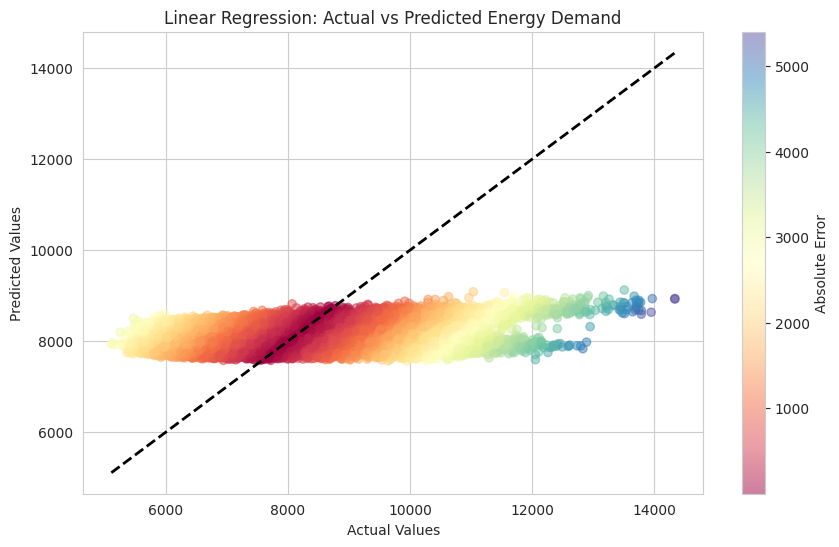

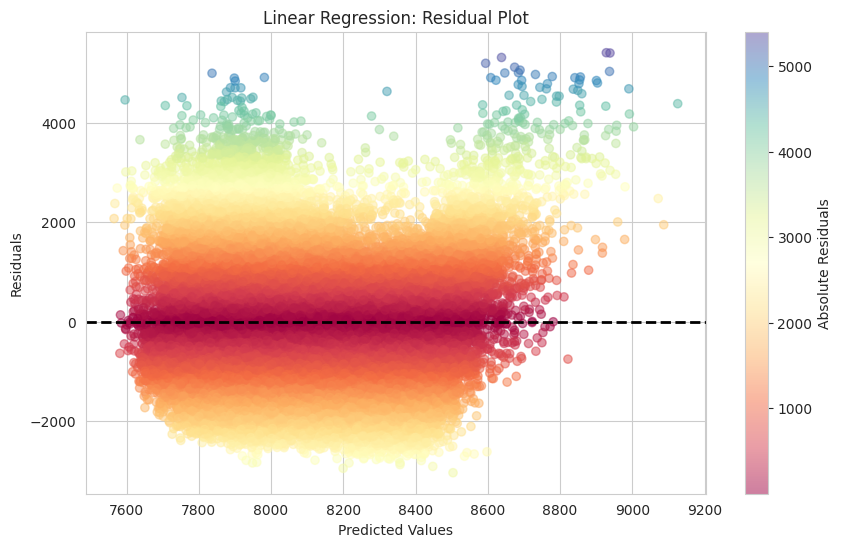

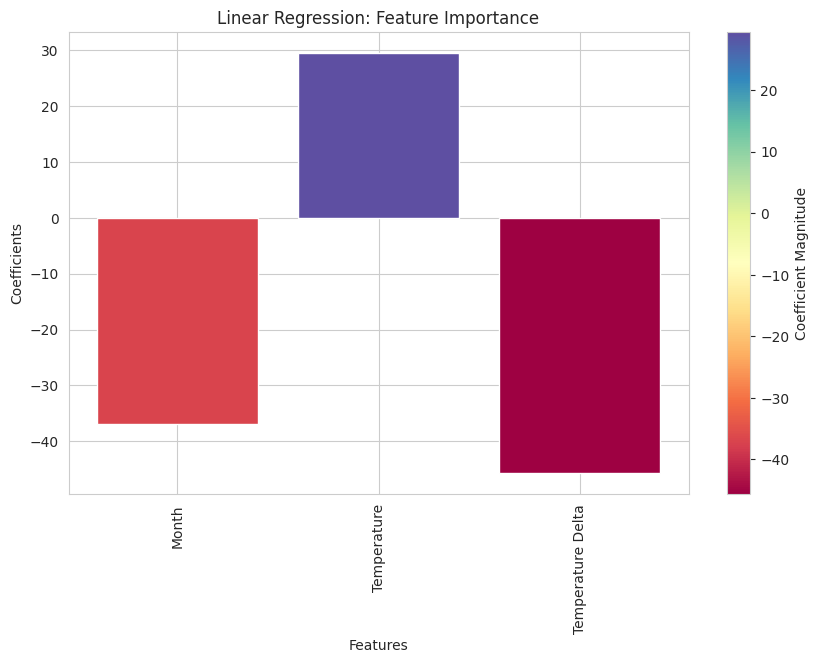

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Assuming 'LOCATION' is the only categorical variable that needs encoding
features_to_encode = ['LOCATION'] if 'LOCATION' in merged_df.columns else []
remaining_features = ['MONTH', 'TEMPERATURE', 'TEMPERATUREDELTA']
features = features_to_encode + remaining_features

# Prepare features X and target y
X = merged_df[features]
y = merged_df['TOTALDEMAND'].values

# Encoding categorical variables if necessary
if features_to_encode:
    column_transformer = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), features_to_encode)], remainder='passthrough')
    X_transformed = column_transformer.fit_transform(X)
else:
    X_transformed = X

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
rmse = mean_squared_error(y_test, y_pred, squared=False)  # Calculate RMSE
print(f'RMSE: {rmse}')


import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import matplotlib

# Check for the best way to access a colormap
def get_colormap(cmap_name):
    try:
        # Try accessing via the new recommended way (for Matplotlib 3.4+)
        return matplotlib.colormaps[cmap_name]
    except AttributeError:
        # Fallback to the old method if not present
        return cm.get_cmap(cmap_name)


spectral = get_colormap('Spectral')

# Assuming y_test and y_pred are defined
plt.figure(figsize=(10, 6))
errors = np.abs(y_test - y_pred)  # Calculate the absolute errors
sc = plt.scatter(y_test, y_pred, c=errors, cmap=spectral, alpha=0.5)
plt.colorbar(sc, label='Absolute Error')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', linestyle='--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Linear Regression: Actual vs Predicted Energy Demand')
plt.show()

residuals = y_test - y_pred  # Calculate residuals

plt.figure(figsize=(10, 6))
sc = plt.scatter(y_pred, residuals, c=np.abs(residuals), cmap=spectral, alpha=0.5)  # Color by the absolute value of residuals
plt.colorbar(sc, label='Absolute Residuals')
plt.axhline(y=0, color='black', linestyle='--', lw=2)  # Black line at 0 for reference
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Linear Regression: Residual Plot')
plt.show()



coefficients = model.coef_
feature_names = ['Month', 'Temperature', 'Temperature Delta']  # Example feature names

norm = plt.Normalize(coefficients.min(), coefficients.max())
norm_coefficients = norm(coefficients)

plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(coefficients)), coefficients, color=spectral(norm_coefficients))
plt.xlabel('Features')
plt.ylabel('Coefficients')
plt.title('Linear Regression: Feature Importance')
plt.xticks(range(len(coefficients)), feature_names, rotation=90)
plt.colorbar(cm.ScalarMappable(norm=norm, cmap=spectral), ax=plt.gca(), label='Coefficient Magnitude')
plt.show()




In [41]:
rmse = mean_squared_error(y_test, y_pred, squared=False)  # Calculate RMSE
r2 = r2_score(y_test, y_pred)  # Calculate R-squared
print(f'Test RMSE: {rmse}')
print(f'Test R2 score: {r2}')

Test RMSE: 1280.718271027504
Test R2 score: 0.031320474080266836


Epoch 1/200

Epoch 1: Validation RMSE = 1476.1352

Epoch 1: val_loss improved from inf to 2178975.00000, saving model to /content/Model/best_model_checkpoint.keras
4928/4928 - 156s - loss: 5412604.0000 - val_loss: 2178975.0000 - lr: 0.0014 - 156s/epoch - 32ms/step
Epoch 2/200

Epoch 2: Validation RMSE = 1549.7912

Epoch 2: val_loss did not improve from 2178975.00000
4928/4928 - 155s - loss: 5096218.5000 - val_loss: 2401852.7500 - lr: 0.0014 - 155s/epoch - 31ms/step
Epoch 3/200

Epoch 3: Validation RMSE = 1340.1988

Epoch 3: val_loss improved from 2178975.00000 to 1796133.87500, saving model to /content/Model/best_model_checkpoint.keras
4928/4928 - 152s - loss: 5089633.0000 - val_loss: 1796133.8750 - lr: 0.0014 - 152s/epoch - 31ms/step
Epoch 4/200

Epoch 4: Validation RMSE = 1980.2743

Epoch 4: val_loss did not improve from 1796133.87500
4928/4928 - 155s - loss: 5045306.5000 - val_loss: 3921487.0000 - lr: 0.0014 - 155s/epoch - 31ms/step
Epoch 5/200

Epoch 5: Validation RMSE = 1390.3349


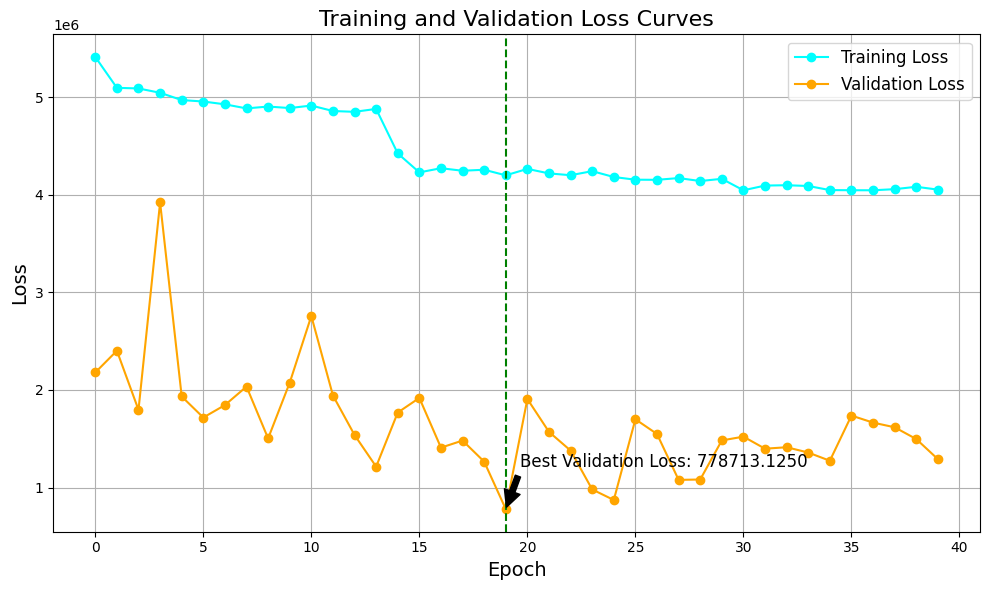

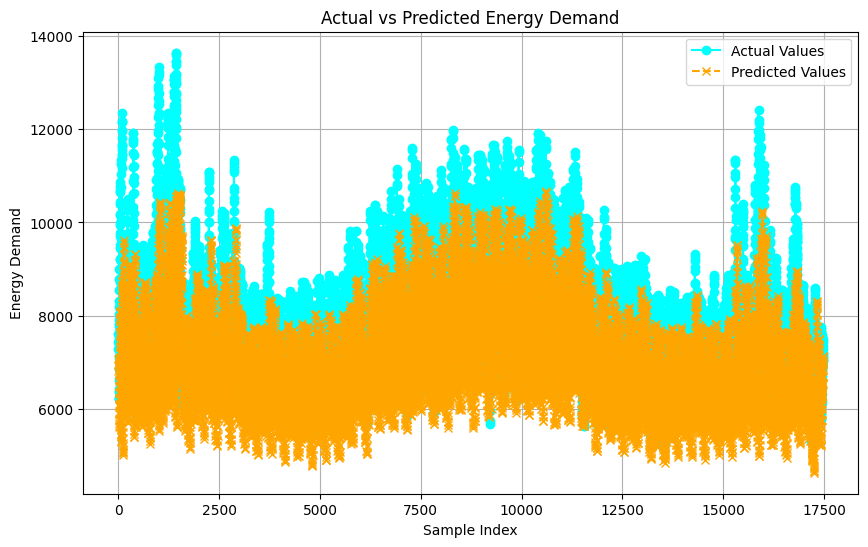

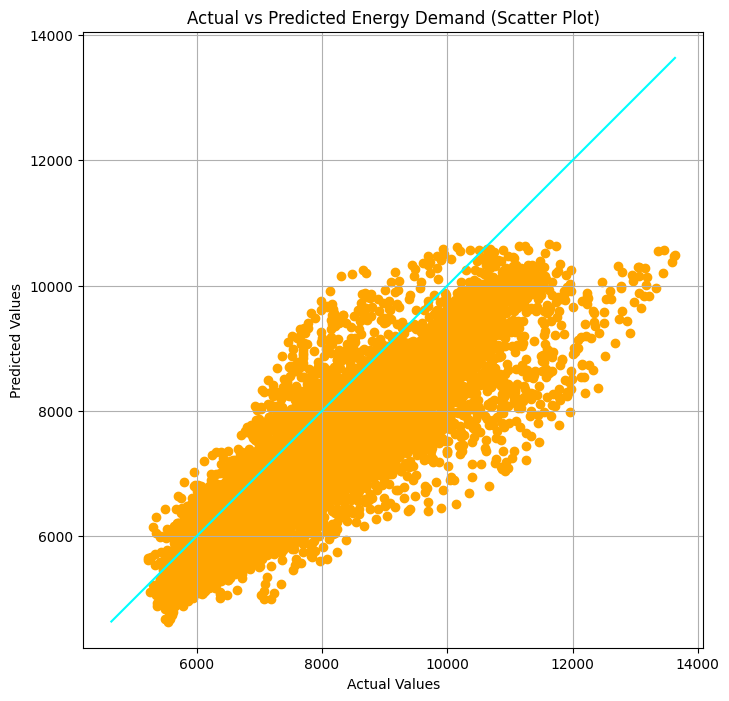

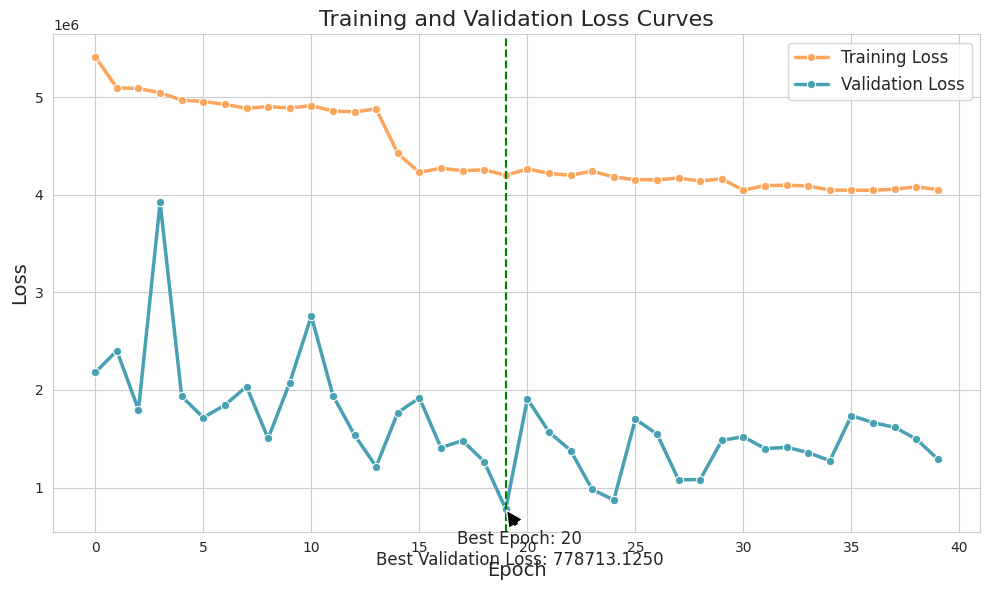

ValueError: Per-column arrays must each be 1-dimensional

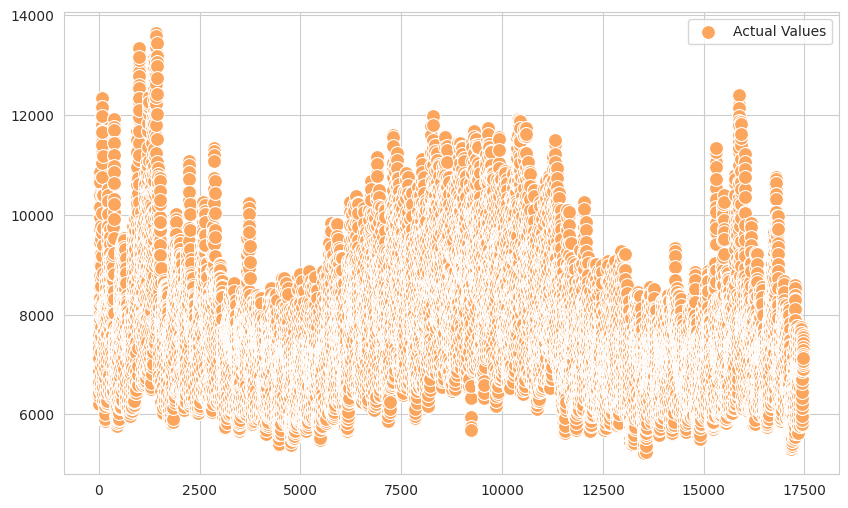

In [ ]:
import json
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv1D, MaxPooling1D, Flatten, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam


with open('/content/ds_project_h03_2024_group_c_data/trial (1).json', 'r') as f:
    tuner_params = json.load(f)


best_hps = tuner_params['hyperparameters']['values']


model = Sequential([
    TimeDistributed(
        Conv1D(
            filters=best_hps['filters'],
            kernel_size=1,
            activation="relu",
        ),
        input_shape=(None, n_steps, n_features),
    ),
    TimeDistributed(MaxPooling1D(pool_size=2)),
    TimeDistributed(Flatten()),
    Bidirectional(
        LSTM(
            units=best_hps['units'],
            activation="relu",
            return_sequences=True,
        )
    ),
    Dropout(rate=best_hps['dropout']),
    LSTM(30, activation="relu"),
    Dropout(0.2),
    Dense(1),
])

model.compile(
    optimizer=Adam(learning_rate=best_hps['learning_rate']),
    loss="mse",
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta=0.001,
    patience=20,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=True
)
# ModelCheckpoint setup
checkpoint_filepath = '/content/Model/best_model_checkpoint.keras'
checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False,
    save_best_only=True,
    monitor='val_loss',
    mode='min',
    verbose=1
)
# Custom Callback to compute validation RMSE (LQ)
class RMSECallback(Callback):
    def __init__(self, X_val, y_val):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val

    def on_epoch_end(self, epoch, logs=None):
        val_predictions = self.model.predict(
            self.X_val, verbose=0
        )  # Use self.model here
        val_rmse = sqrt(mean_squared_error(self.y_val, val_predictions))
        print(f"\nEpoch {epoch+1}: Validation RMSE = {val_rmse:.4f}")


# Instantiate RMSE Callback
rmse_callback = RMSECallback(X_val_seq, y_val_seq)

# Instantiate ReduceLROnPlateau Callback
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=10,
    verbose=1,
    mode='min',
    min_delta=0.0001,
    min_lr=0
)
# Fit the model with callbacks
history = model.fit(
    X_train_seq,
    y_train_seq,
    epochs=200,
    verbose=2,
    validation_data=(X_val_seq, y_val_seq),
    callbacks=[early_stopping, rmse_callback, checkpoint_callback, reduce_lr]
)

# Save the trained model in .keras format
model.save('trained_model.keras')

# Evaluate the best model on the test set
test_loss = model.evaluate(X_test_seq, y_test_seq, verbose=0)
print(f"Test Loss: {test_loss}")

# Evaluate the model on validation data
val_loss = model.evaluate(X_val_seq, y_val_seq, verbose=0)

# Predict and evaluate using the test set
y_pred = model.predict(X_test_seq)

# Calculate RMSE for predictions
rmse = np.sqrt(mean_squared_error(y_test_seq, y_pred))
print(f"Test RMSE: {rmse}")

# R2 score calculation
r2 = r2_score(y_test_seq, y_pred)
print(f"Test R2 Score: {r2}")

## Graphs
import matplotlib.pyplot as plt

# Plot the training and validation loss curves
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', marker='o', color='cyan', linestyle='-')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o', color='orange', linestyle='-')
plt.title('Training and Validation Loss Curves', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.grid(True)
plt.legend(fontsize=12)

# Add vertical line for best epoch
best_epoch = np.argmin(history.history['val_loss'])
best_val_loss = history.history['val_loss'][best_epoch]
plt.axvline(x=best_epoch, color='green', linestyle='--', linewidth=1.5, label=f'Best Epoch: {best_epoch+1}')

# Add annotation for best validation loss
plt.annotate(f'Best Validation Loss: {best_val_loss:.4f}', xy=(best_epoch, best_val_loss),
             xytext=(10, 30), textcoords='offset points',
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12)

plt.tight_layout()
plt.show()

# Plotting the actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test_seq, label="Actual Values", color="cyan", marker="o", linestyle='-')  # Actual values
plt.plot(y_pred, label="Predicted Values", color="orange", linestyle="--", marker="x")  # Predicted values
plt.title("Actual vs Predicted Energy Demand")
plt.xlabel("Sample Index")
plt.ylabel("Energy Demand")
plt.legend()
plt.grid(True)
plt.show()

#scatter plot with perfect prediction line
plt.figure(figsize=(8, 8))
max_val = max(y_test_seq.max(), y_pred.max())
min_val = min(y_test_seq.min(), y_pred.min())
plt.scatter(y_test_seq, y_pred, color="orange")
plt.plot([min_val, max_val], [min_val, max_val], 'cyan')  # Line of perfect predictions
plt.title("Actual vs Predicted Energy Demand (Scatter Plot)")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.grid(True)
plt.axis('equal')
plt.show()

## Graphs
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set Seaborn style and use a specific color palette
sns.set_style("whitegrid")
palette = sns.color_palette("Spectral")

# Assuming 'history' object exists with training and validation loss data
# Plot the training and validation loss curves
plt.figure(figsize=(10, 6))
sns.lineplot(x=range(len(history.history['loss'])), y=history.history['loss'], label='Training Loss', marker='o', linestyle='-', linewidth=2.5, color=palette[1])
sns.lineplot(x=range(len(history.history['val_loss'])), y=history.history['val_loss'], label='Validation Loss', marker='o', linestyle='-', linewidth=2.5, color=palette[5])
plt.title('Training and Validation Loss Curves', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()

# Add vertical line for best epoch
best_epoch = np.argmin(history.history['val_loss'])
best_val_loss = history.history['val_loss'][best_epoch]
plt.axvline(x=best_epoch, color='green', linestyle='--', linewidth=1.5)
plt.annotate(f'Best Epoch: {best_epoch+1}\nBest Validation Loss: {best_val_loss:.4f}', xy=(best_epoch, best_val_loss), xytext=(10, -40),
             textcoords='offset points', arrowprops=dict(facecolor='black', shrink=0.05), fontsize=12, ha='center')
plt.show()




<ipython-input-69-80be938b0f5f>:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  spectral = cm.get_cmap('Spectral', 12)


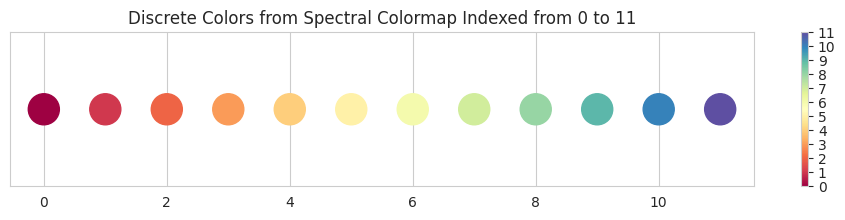

In [69]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Fetch the 'Spectral' colormap
spectral = cm.get_cmap('Spectral', 12)

# Create an array of indices from 0 to 11
indices = np.arange(12)

# Prepare subplot for clarity
fig, ax = plt.subplots(1, figsize=(12, 2))

# Create a color bar using the Spectral colormap
sc = plt.scatter(indices, np.ones_like(indices), c=indices, cmap='Spectral', s=500)
plt.colorbar(sc, ticks=indices)
plt.gca().set_yticks([])  # Hide y ticks
plt.title('Discrete Colors from Spectral Colormap Indexed from 0 to 11')
plt.show()


547/547 [==============================] - 6s 9ms/step


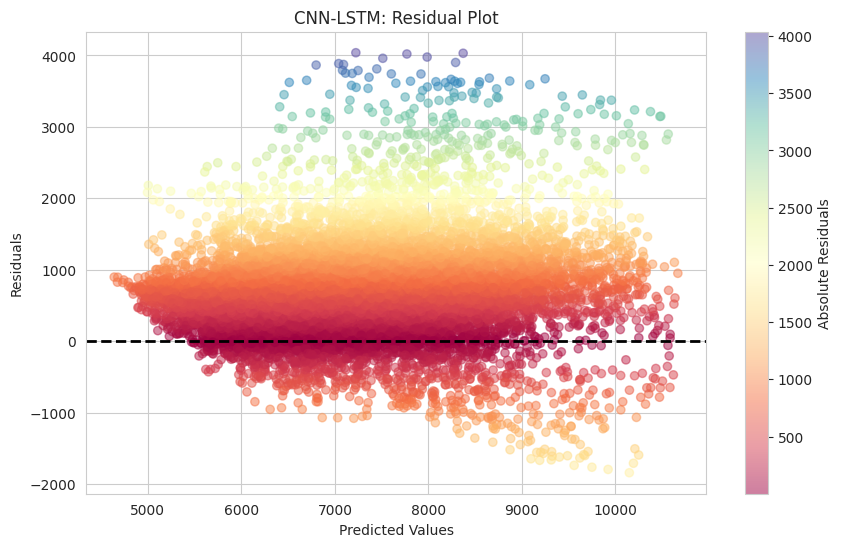

<ipython-input-73-5cad2bd1356a>:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  spectral = cm.get_cmap('Spectral', 12)  # Get 12 discrete colors from the Spectral colormap


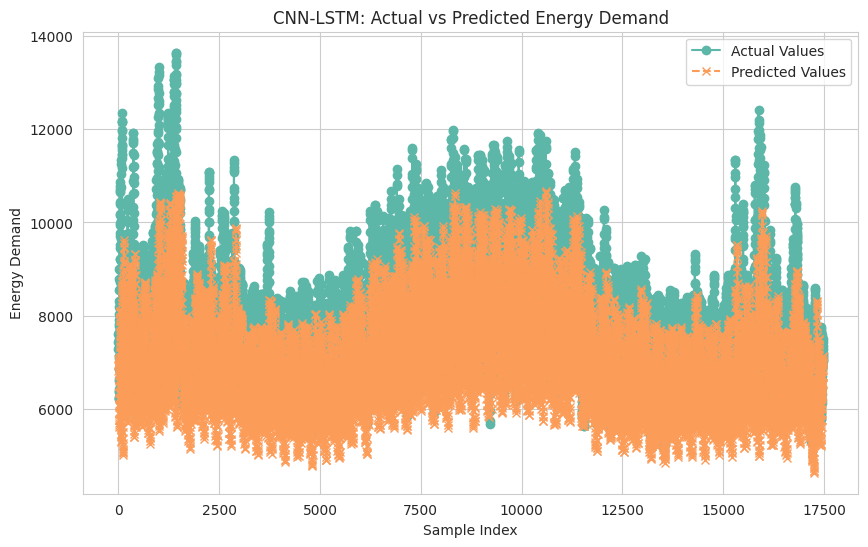

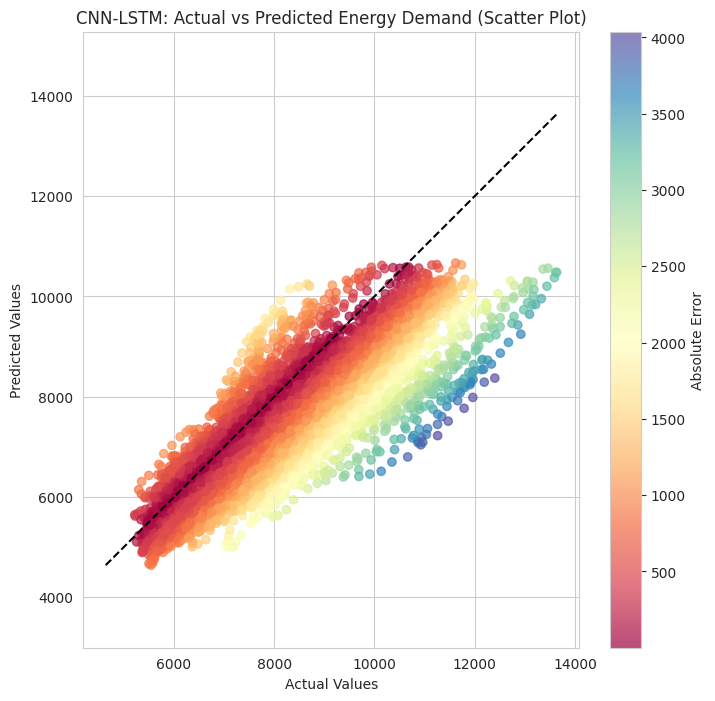

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error

# Load the saved model
loaded_model = load_model('trained_model.keras')

# Predict on the test set
y_pred = loaded_model.predict(X_test_seq)

# Flatten the predictions if necessary
if y_pred.ndim == 2 and y_pred.shape[1] == 1:
    y_pred = y_pred.flatten()

# Calculate residuals
residuals = y_test_seq - y_pred

plt.figure(figsize=(10, 6))
sc = plt.scatter(y_pred, residuals, c=np.abs(residuals), cmap='Spectral', alpha=0.5)
plt.colorbar(sc, label='Absolute Residuals')  # adds a color bar to indicate the values of residuals
plt.axhline(y=0, color='black', linestyle='--', lw=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('CNN-LSTM: Residual Plot')
plt.grid(True)
plt.show()

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm  # Correctly import cm module
# Get the Spectral colormap
spectral = cm.get_cmap('Spectral', 12)  # Get 12 discrete colors from the Spectral colormap

plt.figure(figsize=(10, 6))
plt.plot(y_test_seq, label="Actual Values", color=spectral(9), marker="o", linestyle='-')  # Use a color from Spectral
plt.plot(y_pred, label="Predicted Values", color=spectral(3), linestyle="--", marker="x")  # Use another color from Spectral
plt.title("CNN-LSTM: Actual vs Predicted Energy Demand")
plt.xlabel("Sample Index")
plt.ylabel("Energy Demand")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 8))
max_val = max(max(y_test_seq), max(y_pred))  # max value used for the line of perfect predictions
min_val = min(min(y_test_seq), min(y_pred))  # min value used for the line of perfect predictions

# Create a scatter plot
sc = plt.scatter(y_test_seq, y_pred, c=np.abs(y_test_seq - y_pred), cmap='Spectral', alpha=0.7)
plt.colorbar(sc, label='Absolute Error')  # adds a color bar to indicate the error magnitude

# Line of perfect predictions
plt.plot([min_val, max_val], [min_val, max_val], color='k', linestyle='--')
plt.title("CNN-LSTM: Actual vs Predicted Energy Demand (Scatter Plot)")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.grid(True)
plt.axis('equal')
plt.show()



In [52]:
loaded_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed (TimeDist  (None, None, 48, 96)      3744      
 ributed)                                                        
                                                                 
 time_distributed_1 (TimeDi  (None, None, 24, 96)      0         
 stributed)                                                      
                                                                 
 time_distributed_2 (TimeDi  (None, None, 2304)        0         
 stributed)                                                      
                                                                 
 bidirectional (Bidirection  (None, None, 200)         1924000   
 al)                                                             
                                                                 
 dropout (Dropout)           (None, None, 200)         0

In [60]:
import json

# Load the JSON content
file_path = '/content/ds_project_h03_2024_group_c_data/trial (1).json'
with open(file_path, 'r') as file:
    tuner_data = json.load(file)

# Extract the hyperparameters
best_hps = tuner_data['hyperparameters']['values']

# Print the best hyperparameters
print("Best Hyperparameters:")
for param, value in best_hps.items():
    print(f"{param}: {value}")




Best Hyperparameters:
filters: 96
units: 100
dropout: 0.1
learning_rate: 0.0014114817584581088
tuner/epochs: 10
tuner/initial_epoch: 4
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0022
